# Lesson 02 — CART Regression Loss and Split Selection

## Objective: replace a guessed threshold with a data-driven choice

In Lesson 01, we manually chose `MedInc = 4.0` to split observations into two leaves. This lesson replaces that human guess with the core CART split-selection procedure: generate every meaningful candidate threshold, evaluate the predictions produced by each split, and choose the threshold with the smallest total squared error.

The midpoint thresholds are only the finite set of split proposals that CART needs to test. For each proposal, we will:

1. divide the rows into left (`x ≤ threshold`) and right (`x > threshold`) children;
2. use each child's mean target as its leaf prediction;
3. calculate the squared-error loss in each child;
4. add the child losses to obtain the total split loss; and
5. select the threshold with the lowest total loss.

By the end of the lesson, you should be able to calculate and implement the best split for one feature at one node. We will not yet recurse, grow a complete tree, or consider multiple features.

## Reuse the deterministic California Housing slice

We reuse the same 12 real rows from Lesson 01 so that the new split calculation stays connected to familiar data. The rows are sorted by `MedInc`, making every possible boundary visible between neighboring feature values.

For row $i$:

- $x_i$ is its `MedInc` feature value, measured in units of $10,000; and
- $y_i$ is its observed `MedHouseVal` target, measured in units of $100,000.

The arrays `x` and `y` preserve this displayed order.

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_rows = housing.frame.loc[:, ["MedInc", "MedHouseVal"]]

sorted_rows = (
    housing_rows.reset_index(names="source_row")
    .sort_values(by=["MedInc", "source_row"])
    .reset_index(drop=True)
)

rank_positions = np.linspace(
    0,
    len(sorted_rows) - 1,
    num=12,
    dtype=int,
)

housing_slice = sorted_rows.iloc[rank_positions].reset_index(drop=True)

x = housing_slice["MedInc"].to_numpy()
y = housing_slice["MedHouseVal"].to_numpy()

housing_slice

,source_row,MedInc,MedHouseVal
0,73,0.4999,0.675
1,241,1.8472,1.370
2,3789,2.2756,2.214
3,19601,2.6406,1.297
4,5841,3.0179,2.725
5,5606,3.3427,1.542
6,19373,3.7031,1.733
7,6743,4.1136,2.799
8,16665,4.6071,2.399
9,8554,5.2500,2.472


### Cardinalities in this notebook

**Cardinality** means the number of items in a collection. This lesson works at the root node, so its current node data consists of all 12 rows in our deterministic teaching slice.

| Collection | Notebook object | Cardinality | Meaning |
| --- | --- | ---: | --- |
| Current-node rows | `housing_slice` | 12 | The observations available to this root split |
| Feature values | `x` | 12 | One `MedInc` value per row |
| Target values | `y` | 12 | One `MedHouseVal` value per row |
| Distinct feature values | `unique_x` | 12 | All `MedInc` values happen to be distinct here |
| Candidate thresholds | `thresholds` | 11 | One midpoint between each pair of neighboring distinct feature values |
| Winning left-child targets | `y[left_mask]` | 10 | Targets with $x_i \le 5.7723$ |
| Winning right-child targets | `y[right_mask]` | 2 | Targets with $x_i > 5.7723$ |

The arrays are paired by position: `x[i]` and `y[i]` describe the same row. Therefore `len(x) == len(y) == 12`. Every candidate assigns all current-node rows to exactly one child, so

$$
n_{\mathrm{left}} + n_{\mathrm{right}} = n_{\mathrm{parent}}.
$$

For the selected split, $10 + 2 = 12$. Parent RSS adds 12 squared residuals, left RSS adds 10, and right RSS adds 2. In a full tree, the root would begin with all training rows, while each deeper node would receive only the rows routed to that node; this lesson stops after the one root split.

## Turn one promising gap into a candidate split

By eye, the gap between rows 9 and 10 looks promising because it separates the targets `4.500` and `4.000` from the mostly lower targets before them. We represent that gap with its midpoint threshold:

$$
t = \frac{x_9 + x_{10}}{2} = 5.7723.
$$

Rows with $x_i \le t$ enter the left child; rows with $x_i > t$ enter the right child. Each child predicts the mean of the targets assigned to it:

$$
\hat{y}_L = \operatorname{mean}(y_i : x_i \le t), \qquad \hat{y}_R = \operatorname{mean}(y_i : x_i > t).
$$

These map to `threshold`, `left_mask`, `right_mask`, `left_prediction`, and `right_prediction` in the code below.

In [2]:
threshold = (x[9] + x[10]) / 2

left_mask = x <= threshold
right_mask = x > threshold

left_prediction = y[left_mask].mean()
right_prediction = y[right_mask].mean()

threshold, left_prediction, right_prediction

(np.float64(5.7722999999999995),
 np.float64(1.9226000000000003),
 np.float64(4.25))

### Check the partition

This candidate should send 10 rows left and 2 rows right. The assertions also verify the essential partition rule: every row reaches one child, and no row reaches both children. Passing assertions produce no output.

In [3]:
assert left_mask.sum() == 10
assert right_mask.sum() == 2
assert not (left_mask & right_mask).any()
assert (left_mask | right_mask).all()

## Measure how well this candidate predicts

A **residual** is the difference between an observed target and the prediction it receives. For example, a left-row residual is $y_i - \hat{y}_L$. Squaring prevents negative and positive misses from cancelling.

**RSS stands for Residual Sum of Squares.** A residual is one target-minus-prediction difference; RSS squares those residuals and adds them. In the sums below, $i : x_i \le t$ means ‘each row index $i$ whose feature value $x_i$ is at most the threshold $t$.’ Similarly, $i : x_i > t$ means the rows assigned to the right child. The left and right leaf losses are:

$$
\operatorname{RSS}_L = \sum_{i : x_i \le t}(y_i - \hat{y}_L)^2, \qquad \operatorname{RSS}_R = \sum_{i : x_i > t}(y_i - \hat{y}_R)^2.
$$

The candidate needs one overall score, so we add the child losses:

$$
L_{\mathrm{split}}(t) = \operatorname{RSS}_L + \operatorname{RSS}_R.
$$

In code, these quantities are `left_residuals`, `right_residuals`, `left_loss`, `right_loss`, and `split_loss`. A lower `split_loss` means the two leaf predictions fit their assigned targets more closely.

In [4]:
left_residuals = y[left_mask] - left_prediction
right_residuals = y[right_mask] - right_prediction

# Sum the squared left residuals.
left_loss = (left_residuals**2).sum()

# Sum the squared right residuals.
right_loss = (right_residuals**2).sum()

# Combine both child losses into one candidate score.
split_loss = left_loss + right_loss

left_loss, right_loss, split_loss

(np.float64(4.459686400000001),
 np.float64(0.125),
 np.float64(4.584686400000001))

### Check the candidate score

For this visible split, the left RSS is approximately `4.4597`, the right RSS is `0.125`, and their sum is approximately `4.5847`. `np.isclose` checks these decimal results with a small floating-point tolerance instead of requiring exact binary equality. This score evaluates only the candidate $t = 5.7723$; we have not yet proved that it is the best candidate.

In [5]:
assert np.isclose(left_loss, 4.4596864)
assert np.isclose(right_loss, 0.125)
assert np.isclose(split_loss, left_loss + right_loss)

## Generate every distinct candidate threshold

The candidate $t = 5.7723$ was chosen by eye, but CART must test every grouping that the sorted feature values permit. `np.unique(x)` first removes duplicate feature values because equal values cannot be separated by a threshold.

`left_neighbors` and `right_neighbors` contain the same distinct values shifted by one position. Each aligned pair is one adjacent gap, and its midpoint is the candidate representing that gap. With 12 distinct values, we expect 11 candidates.

In [6]:
# Equal feature values cannot be separated, so keep each value only once.
unique_x = np.unique(x)
print(unique_x)

# Align every distinct value with the distinct value immediately after it.
left_neighbors = unique_x[:-1]
right_neighbors = unique_x[1:]
print(left_neighbors)
print(right_neighbors)

# Represent each adjacent gap with one reproducible midpoint candidate.
thresholds = (left_neighbors + right_neighbors) / 2
thresholds

[ 0.4999  1.8472  2.2756  2.6406  3.0179  3.3427  3.7031  4.1136  4.6071
  5.25    6.2946 15.0001]
[0.4999 1.8472 2.2756 2.6406 3.0179 3.3427 3.7031 4.1136 4.6071 5.25
 6.2946]
[ 1.8472  2.2756  2.6406  3.0179  3.3427  3.7031  4.1136  4.6071  5.25
  6.2946 15.0001]


array([ 1.17355,  2.0614 ,  2.4581 ,  2.82925,  3.1803 ,  3.5229 ,
        3.90835,  4.36035,  4.92855,  5.7723 , 10.64735])

### Check the candidate gaps

The first assertion checks the candidate count. The next two verify that every midpoint lies strictly between its left and right neighboring feature values, so every candidate creates two non-empty children. The final checks anchor the calculation to the visible first and last gaps.

In [7]:
assert thresholds.size == unique_x.size - 1
assert np.all(unique_x[:-1] < thresholds)
assert np.all(thresholds < unique_x[1:])

assert np.isclose(thresholds[0], 1.17355)
assert np.isclose(thresholds[-1], 10.64735)

## Evaluate every candidate with the same rule

The loop below generalizes the one-candidate calculation. Every proposed threshold must first receive its own best possible left and right predictions before its loss can be compared fairly with other thresholds. The evaluation order is:

1. use the proposed threshold to partition the current-node rows;
2. choose the RSS-minimizing prediction for each child;
3. compute left RSS plus right RSS using those predictions; and
4. record that total as the candidate threshold's score.

The derivation at the end of this lesson shows that setting $dL/dp = 0$ makes each child's optimal prediction $p$ equal to its target mean. The loop therefore uses `left_targets.mean()` and `right_targets.mean()` directly instead of repeating the derivative algebra for every candidate.

Each dictionary becomes one row of `candidate_table`. This makes the comparison transparent: the counts show the partition, the predictions show what each leaf returns, and the three loss columns show how the candidate is scored. Only after all rows have been scored does `argmin` select the threshold with the smallest total RSS.

In [8]:
import pandas as pd

# Accumulate one transparent result record for every candidate threshold.
candidate_rows = []
for candidate in thresholds:
    # Partition all targets using this candidate's left/right rule.
    candidate_left_mask = x <= candidate
    candidate_right_mask = x > candidate

    left_targets = y[candidate_left_mask]
    right_targets = y[candidate_right_mask]

    # Each leaf's shared prediction is its own target mean.
    candidate_left_prediction = left_targets.mean()
    candidate_right_prediction = right_targets.mean()

    # Measure each prediction miss before squaring and summing the misses.
    candidate_left_residuals = left_targets - candidate_left_prediction
    candidate_right_residuals = right_targets - candidate_right_prediction

    candidate_left_loss = (candidate_left_residuals**2).sum()
    candidate_right_loss = (candidate_right_residuals**2).sum()

    # Store the partition, predictions, child losses, and combined score.
    candidate_rows.append(
        {
            "threshold": candidate,
            "left_count": left_targets.size,
            "right_count": right_targets.size,
            "left_prediction": candidate_left_prediction,
            "right_prediction": candidate_right_prediction,
            "left_loss": candidate_left_loss,
            "right_loss": candidate_right_loss,
            "total_loss": candidate_left_loss + candidate_right_loss,
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
candidate_table

,threshold,left_count,right_count,left_prediction,right_prediction,left_loss,right_loss,total_loss
0,1.17355,1,11,0.675000,2.459182,0.000000,10.694642,10.694642
1,2.06140,2,10,1.022500,2.568100,0.241513,9.389693,9.631205
2,2.45810,3,9,1.419667,2.607444,1.187961,9.250374,10.438335
3,2.82925,4,8,1.389000,2.771250,1.199246,7.318451,8.517697
4,3.18030,5,7,1.656200,2.777857,2.627163,7.316007,9.943170
5,3.52290,6,6,1.637167,2.983833,2.638031,5.534107,8.172138
6,3.90835,7,5,1.650857,3.234000,2.645903,3.656606,6.302509
7,4.36035,8,4,1.794375,3.342750,3.799356,3.420075,7.219431
8,4.92855,9,3,1.861556,3.657333,4.124308,2.232523,6.356831
9,5.77230,10,2,1.922600,4.250000,4.459686,0.125000,4.584686


### Check the candidate table

There must be exactly one table row per candidate threshold. The child-count checks make the no-empty-child requirement explicit for every candidate, not only for the original worked split.

In [9]:
assert len(candidate_table) == thresholds.size
assert (candidate_table["left_count"] > 0).all()
assert (candidate_table["right_count"] > 0).all()

## Select the minimum-loss candidate

`argmin` returns the position of the smallest value rather than the value itself. Here it finds the position of the smallest `total_loss`. `candidate_table.iloc[best_position]` then retrieves the complete table row at that integer position.

The result is the selected split: threshold `5.7723`, left prediction `1.9226`, right prediction `4.25`, and total RSS `4.584686`.

In [10]:
# Extract the comparable score from every candidate-table row.
total_losses = candidate_table["total_loss"].to_numpy()

# argmin returns the integer position where total loss is smallest.
best_position = total_losses.argmin()

# iloc uses that integer position to retrieve the complete winning row.
best_candidate = candidate_table.iloc[best_position]

best_candidate

threshold            5.772300
left_count          10.000000
right_count          2.000000
left_prediction      1.922600
right_prediction     4.250000
left_loss            4.459686
right_loss           0.125000
total_loss           4.584686
Name: 9, dtype: float64

### Check the selected split

The selected row's loss must equal the minimum loss displayed anywhere in the table. The threshold check also confirms that the automated result matches the promising gap identified earlier by eye.

In [11]:
assert np.isclose(best_candidate["total_loss"], candidate_table["total_loss"].min())
assert np.isclose(best_candidate["threshold"], 5.7723)

## Visualize the selected split and threshold comparison

The left panel shows the model behavior produced by the selected threshold: every row on the left receives one constant prediction, and every row on the right receives another. The right panel shows the numerical search that selected this rule by highlighting the candidate with minimum total RSS. Together, the panels connect the two-step prediction geometry to the split objective.

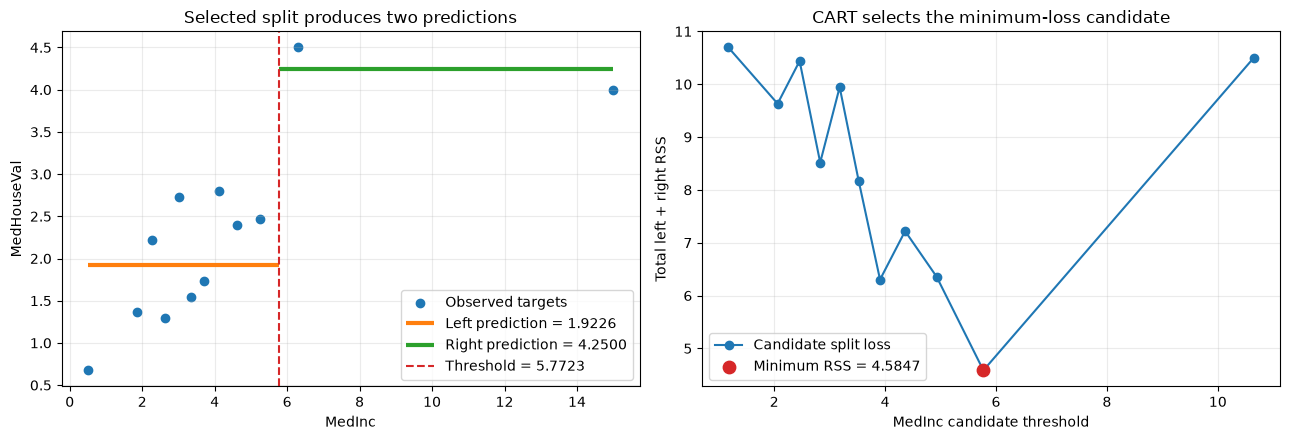

In [12]:
import matplotlib.pyplot as plt

# Values from the candidate selected by minimum total RSS.
best_threshold = float(best_candidate["threshold"])
best_left_prediction = float(best_candidate["left_prediction"])
best_right_prediction = float(best_candidate["right_prediction"])
best_loss = float(best_candidate["total_loss"])

fig, (prediction_ax, loss_ax) = plt.subplots(
    ncols=2,
    figsize=(13, 4.5),
)

# Left panel: observed targets and the selected two-step prediction rule.
prediction_ax.scatter(
    x,
    y,
    color="tab:blue",
    label="Observed targets",
)

prediction_ax.hlines(
    best_left_prediction,
    xmin=x.min(),
    xmax=best_threshold,
    color="tab:orange",
    linewidth=3,
    label=f"Left prediction = {best_left_prediction:.4f}",
)

prediction_ax.hlines(
    best_right_prediction,
    xmin=best_threshold,
    xmax=x.max(),
    color="tab:green",
    linewidth=3,
    label=f"Right prediction = {best_right_prediction:.4f}",
)

prediction_ax.axvline(
    best_threshold,
    color="tab:red",
    linestyle="--",
    label=f"Threshold = {best_threshold:.4f}",
)

prediction_ax.set(
    xlabel="MedInc",
    ylabel="MedHouseVal",
    title="Selected split produces two predictions",
)
prediction_ax.grid(alpha=0.25)
prediction_ax.legend()

# Right panel: the loss used to select that prediction rule.
loss_ax.plot(
    candidate_table["threshold"],
    candidate_table["total_loss"],
    marker="o",
    label="Candidate split loss",
)

loss_ax.scatter(
    best_threshold,
    best_loss,
    color="tab:red",
    s=80,
    zorder=3,
    label=f"Minimum RSS = {best_loss:.4f}",
)

loss_ax.set(
    xlabel="MedInc candidate threshold",
    ylabel="Total left + right RSS",
    title="CART selects the minimum-loss candidate",
)
loss_ax.grid(alpha=0.25)
loss_ax.legend()

fig.tight_layout()
plt.show()

## Compare the selected split with leaving the node unsplit

Finding the smallest candidate loss tells us which split is best, but we also need to know whether splitting improves on the original node. Before a split, the **parent node** contains all 12 rows and predicts their overall target mean, $\bar{y}$. Its loss is the parent RSS:

$$
L_{\mathrm{parent}} = \sum_i (y_i - \bar{y})^2.
$$

The selected split replaces that one prediction with separate left and right predictions. We measure its improvement by subtracting the selected split RSS from the parent RSS:

$$
\text{loss reduction} = L_{\mathrm{parent}} - L_{\mathrm{split}}.
$$

A positive reduction means the two child predictions fit their assigned targets better than the parent's single prediction.

In [13]:
parent_prediction = y.mean()
parent_residuals = y - parent_prediction
parent_loss = (parent_residuals**2).sum()

loss_reduction = parent_loss - best_loss

parent_prediction, parent_loss, best_loss, loss_reduction

(np.float64(2.3105),
 np.float64(13.612670999999999),
 4.584686400000001,
 np.float64(9.027984599999998))

In [14]:
assert np.isclose(parent_loss, 13.612671)
assert np.isclose(loss_reduction, 9.0279846)
assert loss_reduction > 0

## Why does each leaf predict its target mean?

So far, we have used each child's mean target as its prediction. We can now justify that choice: among all possible single-number predictions for a leaf, the mean produces the smallest RSS.

Start with the right child, whose targets are `4.500` and `4.000`. Compare three possible shared predictions:

| Shared prediction $p$ | RSS |
| ---: | ---: |
| $4.00$ | $(4.5 - 4.0)^2 + (4.0 - 4.0)^2 = 0.250$ |
| $4.25$ | $(4.5 - 4.25)^2 + (4.0 - 4.25)^2 = 0.125$ |
| $4.50$ | $(4.5 - 4.5)^2 + (4.0 - 4.5)^2 = 0.250$ |

The mean, $4.25$, gives the smallest value. If we tested many predictions between and beyond these values, their squared-error losses would trace a bowl-shaped curve with its bottom at the mean.

### Introduce the derivative as a slope

Let $p$ be a proposed shared prediction for a leaf containing targets $y_1, \ldots, y_n$. Its RSS is a function of that movable prediction:

$$
L(p) = \sum_{i=1}^{n}(y_i-p)^2.
$$

A **derivative** tells us the slope of this loss curve as $p$ moves. A negative derivative means increasing $p$ moves the loss downhill; a positive derivative means increasing $p$ moves it uphill. At the bottom of the bowl, the slope is zero.

First differentiate one squared residual:

$$
\frac{d}{dp}(y_i-p)^2 = 2(p-y_i).
$$

The sign has changed because the residual contains $-p$. We then add the slopes from all rows, just as RSS adds their squared residuals:

$$
\frac{dL}{dp} = 2\sum_{i=1}^{n}(p-y_i).
$$

### Set the slope to zero

At the minimum, set the derivative equal to zero and solve for the leaf prediction $p$:

$$
2\sum_{i=1}^{n}(p-y_i)=0
$$

$$
n \times p-\sum_{i=1}^{n}y_i=0
$$

$$
p=\frac{1}{n}\sum_{i=1}^{n}y_i=\bar{y}.
$$

Because squared error forms a bowl, this zero-slope point is its minimum. Therefore the RSS-minimizing prediction is the target mean.

CART uses this result while scoring every proposed threshold, not only after choosing the winner. For each threshold, it partitions the rows, uses the mean as the optimal prediction in each child, and computes the resulting left-plus-right RSS. After every threshold has received such an optimized score, the threshold with the smallest total RSS wins.

The symbols map directly to our implementation:

- $y_i$: one value in `left_targets` or `right_targets`;
- $n$: the number of targets in that child;
- $p$: `left_prediction` or `right_prediction`; and
- $\bar{y}$: `left_targets.mean()` or `right_targets.mean()`.

## Put the complete split objective together

Let $T$ be the set of midpoint candidate thresholds. For each proposed threshold $t \in T$, first partition the current-node rows and give each child its RSS-minimizing prediction:

$$
p_L(t)=\operatorname{mean}(y_i:x_i\le t), \qquad p_R(t)=\operatorname{mean}(y_i:x_i>t).
$$

The derivative result $dL/dp=0$ justifies both means. Using those optimized predictions, score the threshold by adding its child losses:

$$
L_{\mathrm{split}}(t)=\sum_{i:x_i\le t}(y_i-p_L(t))^2+\sum_{i:x_i>t}(y_i-p_R(t))^2.
$$

After every candidate has an optimized score, select the threshold where that score is smallest:

$$
t^*=\operatorname*{arg\,min}_{t\in T}L_{\mathrm{split}}(t).
$$

`argmin` returns the candidate's position or value where the loss reaches its minimum; it does not return the minimum loss itself. The symbols map to the notebook as follows:

| Symbol | Meaning | Notebook code |
| --- | --- | --- |
| $T$ | all candidate thresholds | `thresholds` |
| $t$ | one proposed threshold | `candidate` and `threshold` column |
| $p_L(t)$ | optimized left prediction | `candidate_left_prediction` |
| $p_R(t)$ | optimized right prediction | `candidate_right_prediction` |
| $L_{\mathrm{split}}(t)$ | left RSS plus right RSS | `total_loss` |
| $t^*$ | selected threshold | `best_candidate["threshold"]` |

For this slice, $t^*=5.7723$, $p_L=1.9226$, $p_R=4.25$, and the minimum split RSS is $4.5846864$. Because every candidate starts from the same parent RSS, minimizing split RSS is equivalent to maximizing loss reduction.

## Mastery checkpoint and takeaway

Learner takeaway captured from the lesson discussion:

> For each candidate threshold, optimize its left and right leaf predictions. Setting each prediction slope to zero gives the child target mean. Compute the resulting left-plus-right RSS, then select the threshold with the smallest total RSS.

For this root node, threshold `5.7723` wins because its optimized split RSS, `4.5846864`, is the minimum among all 11 candidate thresholds. This lesson stops at one feature and one node; recursive child splitting begins in Lesson 03.